In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rc
from scipy.linalg import null_space
from scipy.linalg import solve as linsolve
from scipy.linalg import svd
from scipy.linalg import eig as eigenvalues
from utils import *
rc('text', usetex=True)
rc('font', family='sans-serif', serif=['Helvetica'], size=18)

## Example: 3-level Rubidium atom #

In [2]:
def HR(Delta, Omega):
    """3-level Rubidium Hamiltonian"""
    Omega1 = Omega
    Omega2 = Omega
    Delta1 = Delta / 10
    Delta2 = Delta
    H = np.array([
        [0, 0, Omega1 / 2],
        [0, Delta1, Omega2 / 2],
        [Omega1 / 2, Omega2 / 2, Delta2]
    ], dtype=complex)
    return H


def LDiss1(r):
    """Dissipator 1 for Rubidium"""
    def func(gamma_d):
        L = gamma_d * np.array([[0, 1, 0], [0, 0, 0], [0, 0, 0]], dtype=complex)
        return lindblad_dissipator(L, r)
    return func


def LDiss2(r):
    """Dissipator 2 for Rubidium"""
    def func(gamma_d):
        L = gamma_d * np.array([[0, 0, 1], [0, 0, 0], [0, 0, 0]], dtype=complex)
        return lindblad_dissipator(L, r)
    return func


def LD1(r):
    """Dephasing dissipator 1 for Rubidium"""
    def func(gamma_phi):
        L = gamma_phi * np.array([[0, 0, 0], [0, 1, 0], [0, 0, -1]], dtype=complex)
        return lindblad_dissipator(L, r)
    return func


def LD2(r):
    """Dephasing dissipator 2 for Rubidium"""
    def func(gamma_phi):
        L = gamma_phi * np.array([[1, 0, 0], [0, 0, 0], [0, 0, -1]], dtype=complex)
        return lindblad_dissipator(L, r)
    return func


def diss(r):
    """Total dissipator for Rubidium system"""
    def func(Delta, Omega):
        gamma_d = 2 * np.pi * 6.1
        gamma_phi = 0.0
        return (LDiss1(r)(gamma_d) + 
                LDiss2(r)(gamma_d) + 
                LD1(r)(gamma_phi) + 
                LD2(r)(gamma_phi))
    return func

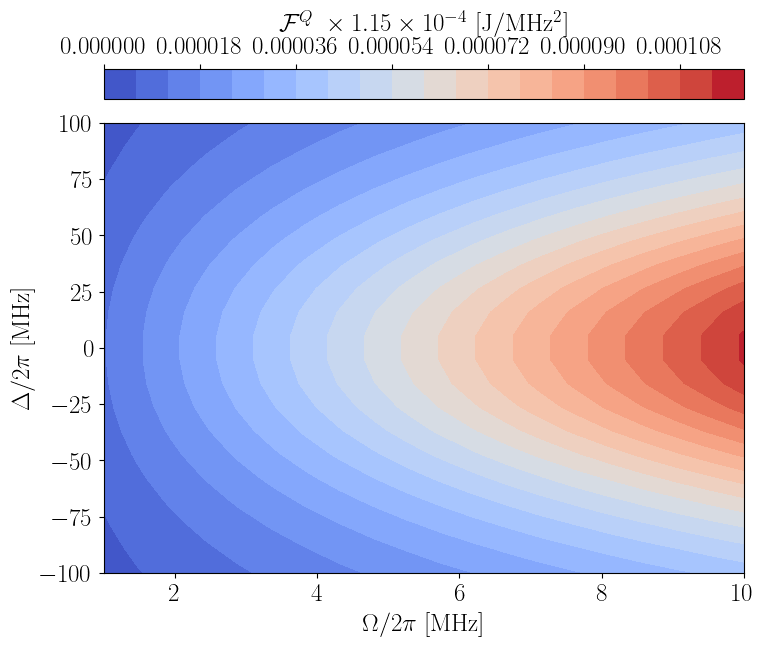

Computing Liouvillian Gap for 3x3 system...
Liouvillian gap between 7.35e+02 and 7.36e+02.


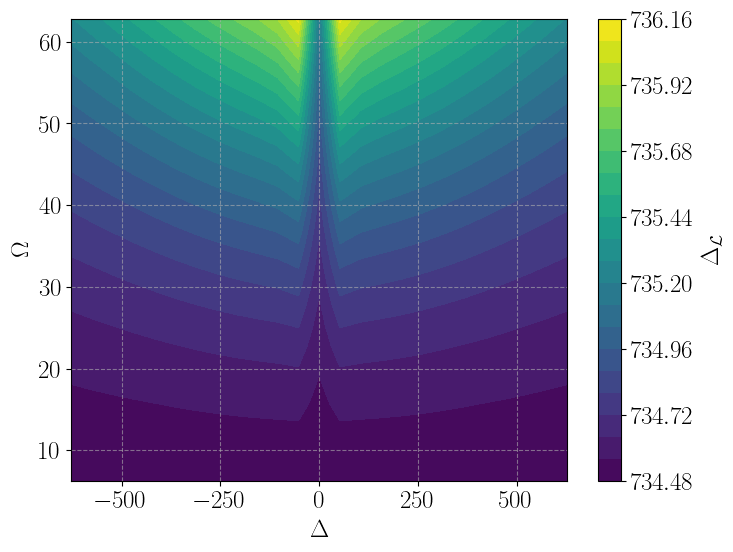

Starting cycle integration for d=3 system...
--- Results ---
Geometric Heat: 3.1667239626152166
Dissipated Heat: 5.671845226568788e-06
Net: 3.166729634460443
Temperature change over the cycle: 2.4188217068395307e-11 K


In [3]:
H1 = HR
range_Delta = [r'$\Delta$', -2 * np.pi * 100, 2 * np.pi * 100] # 2π × [-100, 100] MHz
range_Omega = [r'$\Omega$', 2 * np.pi, 2 * np.pi * 10] # 2π × [1, 10] MHz

p1_grid, p2_grid, curvature_data, max_val = heat_curvature(
    H1, H1, diss,
    ranges=[range_Delta, range_Omega],
    points=20
)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_axes([0.1, 0.08, 0.8, 0.75])
cp = ax.contourf(p2_grid / (2 * np.pi), p1_grid / (2 * np.pi), np.transpose(curvature_data), levels=20, cmap='coolwarm')
cax = fig.add_axes([0.1, 0.87, 0.8, 0.05])
mantissa, exp = f"{max_val:.2e}".split('e')
cbar = fig.colorbar(cp, cax=cax, orientation='horizontal', label=rf'$\mathcal{{F}}^{{Q}} \; \times {mantissa} \times 10^{{{int(exp)}}} \; \mathrm{{[J/MHz^2]}}$')
cbar.ax.xaxis.set_label_position('top')
cbar.ax.xaxis.tick_top()
ax.set_xlabel(r'$\Omega / 2 \pi \; \mathrm{[MHz]}$')
ax.set_ylabel(r'$\Delta / 2 \pi \; \mathrm{[MHz]}$')
plt.savefig('3lvl_Rb.pdf', bbox_inches='tight')
plt.show()

# # Liouvillian Gap Example
# liouvillian_gap(
#     H1,
#     diss,
#     params=[r'$\Delta$', r'$\Omega$'],
#     ranges=[range_Delta,range_Omega],
#     points=25
# )

# # Reversible and Dissipative Heat Example
# # Cycle path goes over the whole parameter range
# q_geo, q_diss = compute_cycle_heats(
#     H1,
#     H1,
#     diss,
#     p_min=[range_Delta[1], range_Omega[1]],
#     p_max=[range_Delta[2], range_Omega[2]],
#     tau= 2* np.pi,
#     points=100
# )

# kB = 1.380649e-23  # Boltzmann constant in J/K
# hbar = 1.0545718e-34  # Reduced Planck constant in J*s
# print("Temperature change over the cycle:", (q_geo + q_diss) * hbar / kB, "K")

## Example: Motion-TLS Coupled System ##

In [4]:
def H_motion_tls(omega_rf, omega_rabi):
    """
    Motion-TLS Hamiltonian.
    omega_rf: RF frequency (variable parameter 1)
    omega_rabi: Rabi frequency (variable parameter 2)
    """
    N_mot = 3
    a_diag_vals = np.sqrt(np.arange(1, N_mot))
    a = np.diag(a_diag_vals, k=1)
    adag = a.T.conj()
    
    # Physical constants
    x0 = 1e-5 # 0-10 \mu m
    omega_mot = 2 * np.pi * 500 # 2 pi 50-500 Hz
    mu_B = 9.27e-24 #  J/T
    gF = 0.5
    B0 = 1e-3 # T
    dB = 1.0 # 100 G/cm = 1 T/m
    hbar = 1.05e-34 # J s
    m = 1.44e-25 # kg
    
    # Oscillator length scale
    x_ho = np.sqrt(hbar / (2 * m * omega_mot))
    eta = gF * mu_B * x_ho * dB / hbar
    delta = omega_rf - gF * mu_B * B0 / hbar
    
    # Hamiltonian components
    H_mot = omega_mot * (np.kron(sigma0, adag @ a) - x0 * np.kron(sigma0, adag + a))
    H_spin = 0.5 * np.kron(delta * sigma3 + omega_rabi * sigma1, np.eye(N_mot))
    H_coup = np.kron(sigma3, -eta * (adag + a))
    
    return H_mot + H_spin + H_coup


def H_motion_tls_ref(omega_rf, omega_rabi):
    """Reference Hamiltonian for Motion-TLS (photon number operator)"""
    N_mot = 3
    a_diag_vals = np.sqrt(np.arange(1, N_mot))
    a = np.diag(a_diag_vals, k=1)
    adag = a.T.conj()
    return np.kron(np.eye(2), adag @ a)


def diss_motion_tls(r):
    """Dissipator for Motion-TLS system"""
    N_mot = 3
    a_diag_vals = np.sqrt(np.arange(1, N_mot))
    a = np.diag(a_diag_vals, k=1)
    adag = a.T.conj()
    
    def func(omega_rf, omega_rabi):

        gamma_up = 1e5 # Hz
        gamma_phi = 100.0 # Hz
        gamma_m = 10.0 # Hz
        n_th = 1000 # thermal photon number
        
        L_up = np.sqrt(gamma_up) * np.kron(sigma_up, np.eye(N_mot))
        L_phi = np.sqrt(gamma_phi / 2) * np.kron(sigma3, np.eye(N_mot))
        L_cool = np.sqrt(gamma_m * (n_th + 1)) * np.kron(np.eye(2), a)
        L_heat = np.sqrt(gamma_m * n_th) * np.kron(np.eye(2), adag)
        
        return (lindblad_dissipator(L_up, r) +
                lindblad_dissipator(L_phi, r) +
                lindblad_dissipator(L_cool, r) +
                lindblad_dissipator(L_heat, r))
    
    return func

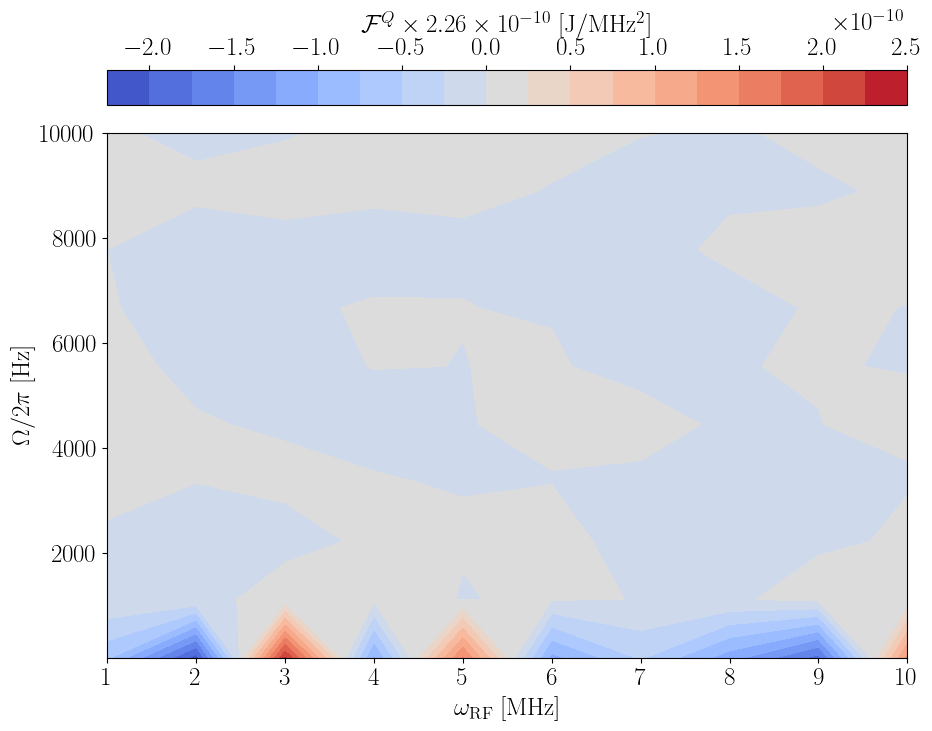

In [6]:
# Heat Curvature
omegaRF_range = [r'$\omega_{\mathrm{RF}}$', 1e6, 1e7] # Hz
Omega_range = [r'$\Omega$', 2 * np.pi * 10, 2 * np.pi * 1e4] # Hz

p1_grid_mtls, p2_grid_mtls, curvature_mtls, max_val_mtls = heat_curvature(
    H_motion_tls, H_motion_tls, diss_motion_tls,
    ranges=[omegaRF_range, Omega_range],
    points=10
)

# Plot Heat Curvature
fig = plt.figure(figsize=(10, 7))
ax = fig.add_axes([0.1, 0.08, 0.8, 0.75])
cp = ax.contourf(p1_grid_mtls / 1e6, p2_grid_mtls / (2 * np.pi), 
                    curvature_mtls, levels=20, cmap='coolwarm')
cax = fig.add_axes([0.1, 0.87, 0.8, 0.05])
mantissa, exp = f"{max_val_mtls:.2e}".split('e')
cbar = fig.colorbar(cp, cax=cax, orientation='horizontal', label=rf'$\mathcal{{F}}^Q \times {mantissa} \times 10^{{{int(exp)}}} \; \mathrm{{[J/MHz^2]}}$')
cbar.ax.xaxis.set_label_position('top')
cbar.ax.xaxis.tick_top()
ax.set_xlabel(r'$\omega_{\mathrm{RF}} \; \mathrm{[MHz]}$')
ax.set_ylabel(r'$\Omega / 2 \pi \; \mathrm{[Hz]}$')
plt.savefig('motion_tls.pdf', bbox_inches='tight')
plt.show()

# # Liouvillian Gap
# liouvillian_gap(
#     H_motion_tls,
#     diss_motion_tls,
#     params=[r'$\omega_{\mathrm{RF}}$', r'$\Omega$'],
#     ranges=[omegaRF_range,Omega_range],
#     points=10
# )

# # Cycle heats
# q_geo_mtls, q_diss_mtls = compute_cycle_heats(
#     H_motion_tls,
#     H_motion_tls,
#     diss_motion_tls,
#     p_min=[omegaRF_range[1], Omega_range[1]],
#     p_max=[omegaRF_range[2], Omega_range[2]],
#     tau=2 * np.pi,
#     points=100
# )

# kB = 1.380649e-23  # Boltzmann constant in J/K
# hbar = 1.0545718e-34  # Reduced Planck constant in J*s
# print("Temperature change over the cycle:", (q_geo_mtls + q_diss_mtls) * hbar / kB, "K")